In [9]:
import numpy as np

def fft_1024_radix2(x):
    N = len(x)
    stages = int(np.log2(N)) # 10 etapas para N=1024

    # 1. Ordenamiento de datos (Bit-reversal)
    X = np.zeros(N, dtype=complex)
    for i in range(N):
        rev_i = int('{:010b}'.format(i)[::-1], 2)
        X[rev_i] = x[i]

    # 2. Estructura de las 10 etapas y calculo por mariposas
    for stage in range(1, stages + 1):
        distancia = 2 ** stage
        half_dist = distancia // 2
        W_N = np.exp(-2j * np.pi / distancia) # Factores de giro

        # Iteracion sobre los bloques de mariposas
        for k in range(0, N, distancia):
            W = 1
            for j in range(half_dist):
                # Operacion basica de la mariposa
                rama_sup = X[k + j]
                rama_inf = W * X[k + j + half_dist]

                # Cruces
                X[k + j] = rama_sup + rama_inf
                X[k + j + half_dist] = rama_sup - rama_inf

                # Actualizacion del factor de giro
                W = W * W_N

    return X

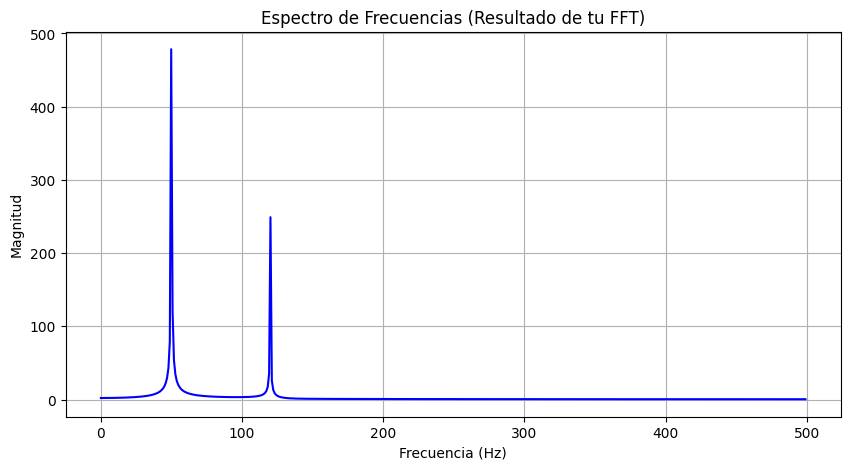

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. TU FUNCIÓN EXACTA
def fft_1024_radix2(x):
    N = len(x)
    stages = int(np.log2(N))

    X = np.zeros(N, dtype=complex)
    for i in range(N):
        rev_i = int('{:010b}'.format(i)[::-1], 2)
        X[rev_i] = x[i]

    for stage in range(1, stages + 1):
        distancia = 2 ** stage
        half_dist = distancia // 2
        W_N = np.exp(-2j * np.pi / distancia)

        for k in range(0, N, distancia):
            W = 1
            for j in range(half_dist):
                rama_sup = X[k + j]
                rama_inf = W * X[k + j + half_dist]

                X[k + j] = rama_sup + rama_inf
                X[k + j + half_dist] = rama_sup - rama_inf

                W = W * W_N

    return X

# ==========================================
# 2. LA PRUEBA
# ==========================================

# Generamos un vector de tiempo para 1024 muestras
F_muestreo = 1000 # Frecuencia de muestreo (1000 Hz)
t = np.linspace(0, 1024/F_muestreo, 1024, endpoint=False)

# Creamos una señal mezclando dos frecuencias conocidas: 50 Hz y 120 Hz
senal_prueba = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# Llamamos a tu función de la FFT
resultado_fft = fft_1024_radix2(senal_prueba)

# ==========================================
# 3. GRAFICAR
# ==========================================

# Calculamos la magnitud de los números complejos que devolvió tu función
magnitud = np.abs(resultado_fft)
frecuencias = np.linspace(0, F_muestreo, 1024, endpoint=False)

# Graficamos solo la primera mitad (hasta N/2) por la simetría de Nyquist
plt.figure(figsize=(10, 5))
plt.plot(frecuencias[:512], magnitud[:512], color='blue')
plt.title("Espectro de Frecuencias (Resultado de tu FFT)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.grid(True)
plt.show()